<a href="https://colab.research.google.com/github/sarahibadi/keras-monkeys/blob/main/Monkeys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install -U tensorflow tensorflow_hub kaggle

from google.colab import drive
drive.mount('/content/drive')

!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets list -s "monkey"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.19.1 which is incompatible.
Mounted at /content/drive
ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
slothkong/10-monkey-species                                     10 Monkey Species                                   573619322  2018-06-28 01:38:58.887000          32025        515  0.8125           
deep

In [2]:
import os
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

!kaggle datasets download -d slothkong/10-monkey-species -p {DATA_DIR}
!unzip -q -o {DATA_DIR}/10-monkey-species.zip -d {DATA_DIR}

!ls -R {DATA_DIR} | head -40

Dataset URL: https://www.kaggle.com/datasets/slothkong/10-monkey-species
License(s): CC0-1.0
 96% 523M/547M [00:01<00:00, 283MB/s]
100% 547M/547M [00:01<00:00, 358MB/s]
/content/data:
10-monkey-species.zip
monkey_labels.txt
training
validation

/content/data/training:
training

/content/data/training/training:
n0
n1
n2
n3
n4
n5
n6
n7
n8
n9

/content/data/training/training/n0:
n0018.jpg
n0019.jpg
n0020.jpg
n0021.jpg
n0022.jpg
n0023.jpg
n0024.jpg
n0025.jpg
n0026.jpg
n0027.jpg
n0028.jpg
n0029.jpg
n0030.jpg
n0031.jpg
n0032.jpg
n0033.jpg
n0034.jpg
n0035.jpg


In [3]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np, matplotlib.pyplot as plt, pandas as pd, datetime, json, pathlib

train_dir = pathlib.Path(f"{DATA_DIR}/training/training")
val_dir   = pathlib.Path(f"{DATA_DIR}/validation/validation")
test_dir  = pathlib.Path(f"{DATA_DIR}/testing/testing")

class_names = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
num_classes = len(class_names)
print("Classes:", class_names)

Classes: ['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 123
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, seed=SEED
)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.Rescaling(1./255)
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)

Found 1097 files belonging to 10 classes.
Found 272 files belonging to 10 classes.


In [5]:
HUB_URL = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

from tensorflow.keras import layers, models
import tensorflow as tf

IMG_SIZE = 224

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = data_augmentation(x)
x = base_model(x, training=False)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

model.summary()





9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
EPOCHS = 10
LR = 1e-3
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)


Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.0779 - loss: 2.4820 - val_accuracy: 0.0956 - val_loss: 2.3129
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.1026 - loss: 2.4649 - val_accuracy: 0.0882 - val_loss: 2.3359
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.0975 - loss: 2.4421 - val_accuracy: 0.1140 - val_loss: 2.3384
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.0824 - loss: 2.4739 - val_accuracy: 0.1029 - val_loss: 2.3295
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.1043 - loss: 2.4172 - val_accuracy: 0.0956 - val_loss: 2.4407
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.0897 - loss: 2.4994 - val_accuracy: 0.0993 - val_loss: 2.3678
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.0814 - loss: 2.4322 - val_accuracy: 0.0735 - val_loss: 2.3215
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.1032 - loss: 2.4034 - val_accuracy: 0.1029 - val_

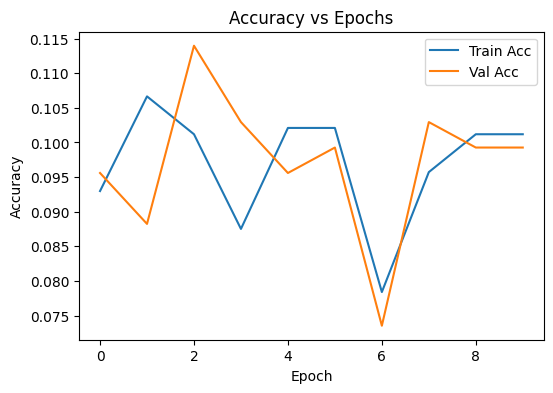

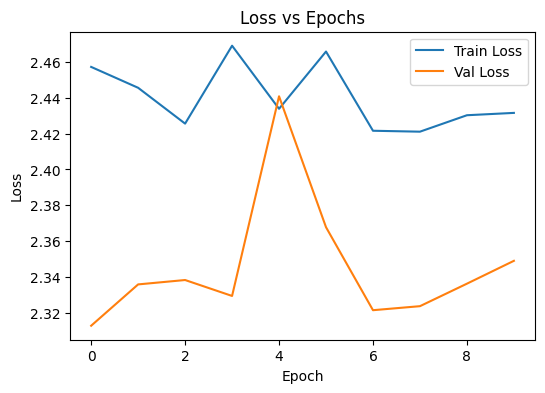

In [7]:

hist = history.history
plt.figure(figsize=(6,4))
plt.plot(hist["accuracy"], label="Train Acc")
plt.plot(hist["val_accuracy"], label="Val Acc")
plt.title("Accuracy vs Epochs"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(hist["loss"], label="Train Loss")
plt.plot(hist["val_loss"], label="Val Loss")
plt.title("Loss vs Epochs"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


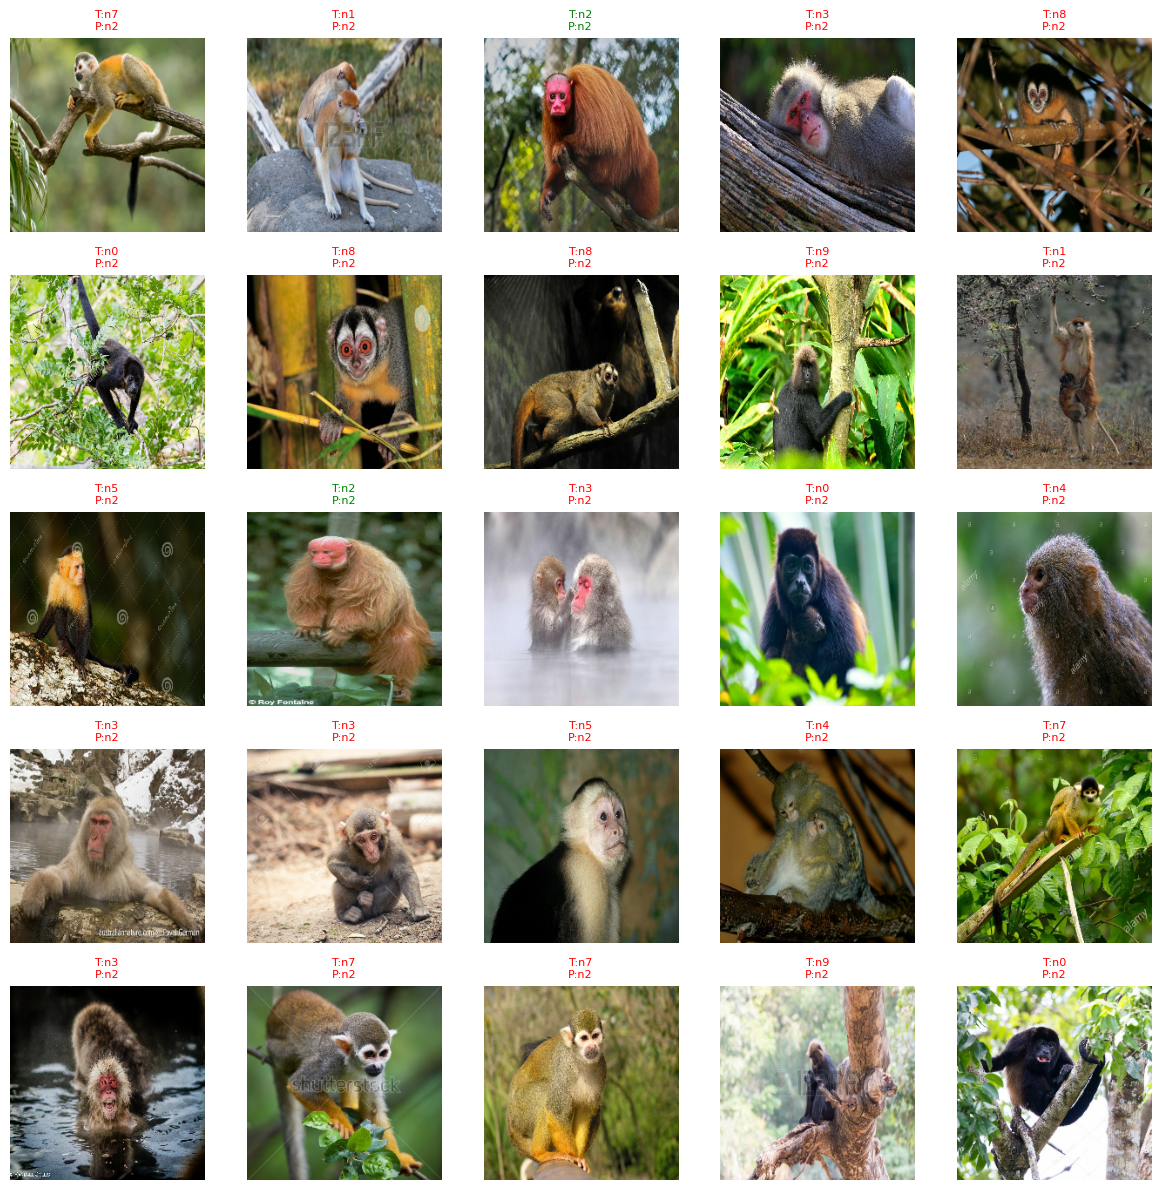

In [8]:
image_batch, label_batch = next(iter(val_ds.unbatch().batch(25)))
pred_probs = model.predict(image_batch)
pred_labels = tf.argmax(pred_probs, axis=1)

plt.figure(figsize=(12,12))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    true_name = class_names[label_batch[i]]
    pred_name = class_names[pred_labels[i]]
    color = "green" if true_name == pred_name else "red"
    plt.title(f"T:{true_name}\nP:{pred_name}", color=color, fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [9]:
base_model.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Starting fine-tuning...")
ft_history = model.fit(train_ds, validation_data=val_ds, epochs=5)


Starting fine-tuning...
Epoch 1/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 390s 9s/step - accuracy: 0.0990 - loss: 2.5945 - val_accuracy: 0.0993 - val_loss: 2.3673
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 330s 9s/step - accuracy: 0.1440 - loss: 2.4232 - val_accuracy: 0.0993 - val_loss: 2.3457
Epoch 3/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 341s 9s/step - accuracy: 0.1937 - loss: 2.2486 - val_accuracy: 0.0993 - val_loss: 2.3494
Epoch 4/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 330s 8s/step - accuracy: 0.1908 - loss: 2.2268 - val_accuracy: 0.1029 - val_loss: 2.3735
Epoch 5/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 366s 9s/step - accuracy: 0.2292 - loss: 2.1022 - val_accuracy: 0.1250 - val_loss: 2.3923


In [10]:
import datetime, os
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
SAVE_DIR = f"/content/drive/MyDrive/keras-monkeys-{timestamp}"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(f"{SAVE_DIR}/monkey_model.keras")
with open(f"{SAVE_DIR}/class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)
print("Saved model and class names to:", SAVE_DIR)


Saved model and class names to: /content/drive/MyDrive/keras-monkeys-20251109-054421


In [11]:
tuning_results = pd.DataFrame([
    {"Iteration":1, "Parameters":"lr=1e-3, dropout=0.2, epochs=10", "Train Acc":hist["accuracy"][-1], "Val Acc":max(hist["val_accuracy"])},
    {"Iteration":2, "Parameters":"lr=1e-5 (fine-tune), dropout=0.2, epochs=5", "Train Acc":ft_history.history["accuracy"][-1], "Val Acc":max(ft_history.history["val_accuracy"])},
])
tuning_results.to_csv(f"{SAVE_DIR}/param_tuning_summary.csv", index=False)
tuning_results


,Iteration,Parameters,Train Acc,Val Acc
0,1,"lr=1e-3, dropout=0.2, epochs=10",0.101185,0.113971
1,2,"lr=1e-5 (fine-tune), dropout=0.2, epochs=5",0.235187,0.125000
